In [24]:
import pandas as pd
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler 
from sklearn.metrics import confusion_matrix , classification_report




In [25]:
FILE_PATH = 'Indian Sign Language Gesture Landmarks.csv'

df = pd.read_csv(FILE_PATH)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (50859, 128)


,target,uses_two_hands,left_hand_x_0,left_hand_y_0,left_hand_z_0,left_hand_x_1,left_hand_y_1,left_hand_z_1,left_hand_x_2,left_hand_y_2,...,right_hand_z_17,right_hand_x_18,right_hand_y_18,right_hand_z_18,right_hand_x_19,right_hand_y_19,right_hand_z_19,right_hand_x_20,right_hand_y_20,right_hand_z_20
0,0,1.0,0.253815,0.683926,-5.182993e-07,0.334322,0.628995,-0.036808,0.395115,0.536168,...,-0.056916,0.734651,0.636123,-0.077313,0.728371,0.649146,-0.074293,0.740377,0.632456,-0.069335
1,0,1.0,0.239443,0.705979,-4.334263e-07,0.328341,0.643167,-0.034284,0.391720,0.545824,...,-0.045846,0.735422,0.631766,-0.067937,0.729320,0.651621,-0.065840,0.745230,0.634763,-0.060055
2,0,1.0,0.235131,0.710337,-4.203069e-07,0.326313,0.646435,-0.033129,0.391156,0.544003,...,-0.042498,0.734292,0.634359,-0.065477,0.730437,0.652772,-0.064716,0.748273,0.633010,-0.060026
3,0,1.0,0.238261,0.711585,-4.149002e-07,0.327710,0.649296,-0.032600,0.392238,0.548713,...,-0.042183,0.733915,0.635711,-0.064914,0.731558,0.652528,-0.064770,0.750294,0.631503,-0.060443
4,0,1.0,0.240304,0.714531,-4.118573e-07,0.329382,0.651202,-0.032841,0.392812,0.550876,...,-0.042013,0.733413,0.637619,-0.066194,0.731997,0.653156,-0.066500,0.751490,0.631916,-0.062321


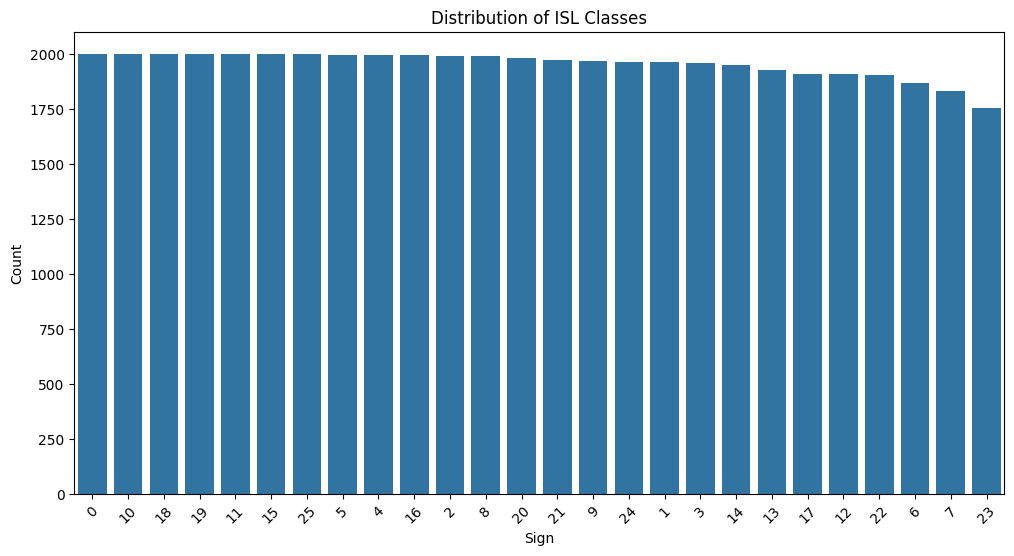

In [26]:
# Assuming the column with the letters is named 'label' or 'class'
# Update 'TARGET_COL' if your dataset uses a different name!
TARGET_COL = 'target' 

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x=TARGET_COL, order=df[TARGET_COL].value_counts().index)
plt.title("Distribution of ISL Classes")
plt.xlabel("Sign")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [27]:
X = df.drop(columns=['target', 'uses_two_hands'])
y = df['target']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
NUM_CLASSES = len(label_encoder.classes_)
print(f"Total Classes : {NUM_CLASSES}")
print(f"Classes Map: {dict(enumerate(label_encoder.classes_))}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


Total Classes : 26
Classes Map: {0: np.int64(0), 1: np.int64(1), 2: np.int64(2), 3: np.int64(3), 4: np.int64(4), 5: np.int64(5), 6: np.int64(6), 7: np.int64(7), 8: np.int64(8), 9: np.int64(9), 10: np.int64(10), 11: np.int64(11), 12: np.int64(12), 13: np.int64(13), 14: np.int64(14), 15: np.int64(15), 16: np.int64(16), 17: np.int64(17), 18: np.int64(18), 19: np.int64(19), 20: np.int64(20), 21: np.int64(21), 22: np.int64(22), 23: np.int64(23), 24: np.int64(24), 25: np.int64(25)}
X_train shape: (40687, 126)
X_test shape: (10172, 126)


In [28]:
INPUT_SHAPE = X_train.shape[1]

model = Sequential([
    Dense(256, activation='relu', input_shape=(INPUT_SHAPE,)),
    BatchNormalization(),
    Dropout(0.3),
    

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

d:\Project\ISL\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        32,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,146 (301.35 KB)

 Trainable params: 76,250 (297.85 KB)

 Non-trainable params: 896 (3.50 KB)

In [29]:

checkpoint = ModelCheckpoint("isl_landmark_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/100
1255/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6503 - loss: 1.2272
Epoch 1: val_accuracy improved from None to 0.96825, saving model to isl_landmark_model.h5


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7993 - loss: 0.6806 - val_accuracy: 0.9682 - val_loss: 0.1151
Epoch 2/100
1263/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9209 - loss: 0.2539
Epoch 2: val_accuracy improved from 0.96825 to 0.98112, saving model to isl_landmark_model.h5


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9313 - loss: 0.2204 - val_accuracy: 0.9811 - val_loss: 0.0602
Epoch 3/100
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9465 - loss: 0.1664
Epoch 3: val_accuracy improved from 0.98112 to 0.98751, saving model to isl_landmark_model.h5


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9491 - loss: 0.1581 - val_accuracy: 0.9875 - val_loss: 0.0440
Epoch 4/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9546 - loss: 0.1383
Epoch 4: val_accuracy improved from 0.98751 to 0.99046, saving model to isl_landmark_model.h5


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9590 - loss: 0.1267 - val_accuracy: 0.9905 - val_loss: 0.0368
Epoch 5/100
1270/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9641 - loss: 0.1117
Epoch 5: val_accuracy improved from 0.99046 to 0.99155, saving model to isl_landmark_model.h5


...

1272/1272 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9908 - loss: 0.0304 - val_accuracy: 0.9974 - val_loss: 0.0094
Epoch 43/100
1269/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9913 - loss: 0.0292
Epoch 43: val_accuracy improved from 0.99744 to 0.99754, saving model to isl_landmark_model.h5


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9918 - loss: 0.0274 - val_accuracy: 0.9975 - val_loss: 0.0088
Epoch 44/100
1266/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9913 - loss: 0.0281
Epoch 44: val_accuracy did not improve from 0.99754
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9920 - loss: 0.0256 - val_accuracy: 0.9975 - val_loss: 0.0099
Epoch 45/100
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9921 - loss: 0.0247
Epoch 45: val_accuracy did not improve from 0.99754
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9912 - loss: 0.0270 - val_accuracy: 0.9974 - val_loss: 0.0105
Epoch 46/100
1265/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.0280
Epoch 46: val_accuracy improved from 0.99754 to 0.99764, saving model to isl_landmark_model.h5


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9907 - loss: 0.0293 - val_accuracy: 0.9976 - val_loss: 0.0102
Epoch 47/100
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.0266
Epoch 47: val_accuracy did not improve from 0.99764
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9973 - val_loss: 0.0121
Epoch 48/100
1265/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 0.0260
Epoch 48: val_accuracy did not improve from 0.99764
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9915 - loss: 0.0255 - val_accuracy: 0.9964 - val_loss: 0.0136
Epoch 49/100
1270/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9907 - loss: 0.0277
Epoch 49: val_accuracy did not improve from 0.99764
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9911 - loss: 0.0277 - val_accuracy: 0.9971 - val_loss: 0.0099
Epoch 50/100
1261/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9903 - loss: 0.0296
Epoc

1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9984 - val_loss: 0.0071
Epoch 53/100
1267/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9916 - loss: 0.0252
Epoch 53: val_accuracy did not improve from 0.99843
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9921 - loss: 0.0247 - val_accuracy: 0.9971 - val_loss: 0.0101
Epoch 54/100
1253/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9933 - loss: 0.0213
Epoch 54: val_accuracy did not improve from 0.99843
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 0.9969 - val_loss: 0.0119
Epoch 55/100
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9921 - loss: 0.0234
Epoch 55: val_accuracy did not improve from 0.99843
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9927 - loss: 0.0230 - val_accuracy: 0.9977 - val_loss: 0.0093
Epoch 56/100
1265/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9917 - loss: 0.0251
Epoch 56

1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9985 - val_loss: 0.0079
Epoch 60/100
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0206
Epoch 60: val_accuracy did not improve from 0.99853
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9937 - loss: 0.0204 - val_accuracy: 0.9982 - val_loss: 0.0084
Epoch 61/100
1258/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9939 - loss: 0.0206
Epoch 61: val_accuracy did not improve from 0.99853
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9939 - loss: 0.0206 - val_accuracy: 0.9978 - val_loss: 0.0091
Epoch 62/100
1262/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9936 - loss: 0.0200
Epoch 62: val_accuracy did not improve from 0.99853
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9932 - loss: 0.0225 - val_accuracy: 0.9984 - val_loss: 0.0079
Epoch 63/100
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9926 - loss: 0.0217
Epoch 63

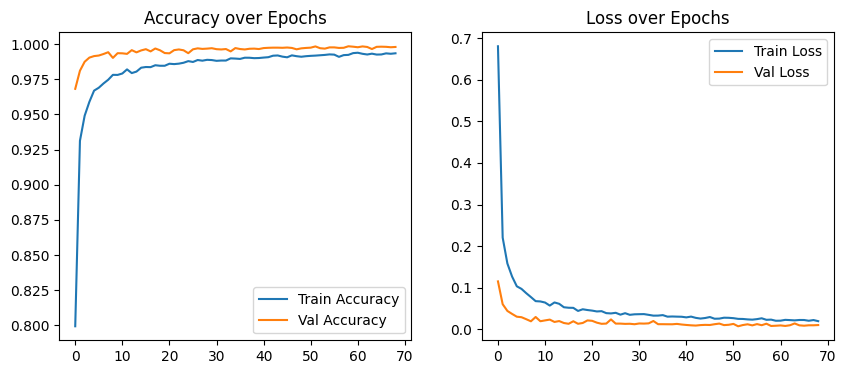

Final Test Accuracy: 99.85%


In [30]:

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("✅ Scaler and Label Encoder saved successfully!")

✅ Scaler and Label Encoder saved successfully!


: 